In [0]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"WARN WindowExpression: No Partition Defined.*",
    category=UserWarning
)

# 05 — GMV Decomposition

## Objective

Decompose monthly booked GMV changes into two business drivers:

- **Order volume effect:** Change caused by the number of orders.
- **AOV effect:** Change caused by average order value.

Because:

\[
Booked\ GMV = Order\ Count \times AOV
\]

A symmetric decomposition is used so that the two effects reconcile exactly with the total GMV change. Partial months are excluded from monthly comparisons.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

monthly_kpis = spark.table("workspace.olist.monthly_kpis")

display(
    monthly_kpis
    .select("purchase_month", "booked_gmv", "order_count", "aov", "coverage_pct")
    .orderBy("purchase_month")
)

purchase_month,booked_gmv,order_count,aov,coverage_pct
2017-01-01,137006.76,787,174.087370,87.09677419354838
2017-02-01,283621.94,1718,165.088440,100.0
2017-03-01,425656.40,2617,162.650516,100.0
2017-04-01,405988.38,2377,170.798645,100.0
2017-05-01,582926.16,3640,160.144549,100.0
2017-06-01,499827.47,3205,155.952409,100.0
2017-07-01,578858.58,3946,146.695028,100.0
2017-08-01,662071.77,4272,154.979347,100.0
2017-09-01,717195.22,4227,169.670031,100.0
2017-10-01,764785.28,4547,168.195575,100.0


In [0]:
month_window = Window.orderBy("purchase_month")

decomposition_base = (
    monthly_kpis
    .withColumn("aov_exact", F.col("booked_gmv") / F.col("order_count"))
    .withColumn("previous_month", F.lag("purchase_month").over(month_window))
    .withColumn("previous_gmv", F.lag("booked_gmv").over(month_window))
    .withColumn("previous_order_count", F.lag("order_count").over(month_window))
    .withColumn("previous_aov", F.lag("aov_exact").over(month_window))
    .withColumn("previous_coverage_pct", F.lag("coverage_pct").over(month_window))
)

In [0]:
monthly_gmv_decomposition = (
    decomposition_base
    .filter(
        (F.col("coverage_pct") == 100) &
        (F.col("previous_coverage_pct") == 100) &
        (F.months_between("purchase_month", "previous_month") == 1)
    )
    .withColumn("gmv_change", F.col("booked_gmv") - F.col("previous_gmv"))
    .withColumn("order_change", F.col("order_count") - F.col("previous_order_count"))
    .withColumn("aov_change", F.col("aov_exact") - F.col("previous_aov"))
    .withColumn(
        "volume_effect",
        F.col("order_change") * (F.col("aov_exact") + F.col("previous_aov")) / 2
    )
    .withColumn(
        "aov_effect",
        F.col("aov_change") * (F.col("order_count") + F.col("previous_order_count")) / 2
    )
    .withColumn(
        "reconciliation_difference",
        F.col("gmv_change") - F.col("volume_effect") - F.col("aov_effect")
    )
)

In [0]:
display(
    monthly_gmv_decomposition
    .filter(F.col("purchase_month") >= "2018-01-01")
    .select(
        "purchase_month",
        F.round("gmv_change", 2).alias("gmv_change"),
        "order_change",
        F.round("aov_change", 2).alias("aov_change"),
        F.round("volume_effect", 2).alias("volume_effect"),
        F.round("aov_effect", 2).alias("aov_effect"),
        F.round("reconciliation_difference", 6).alias("reconciliation_difference")
    )
    .orderBy("purchase_month")
)

purchase_month,gmv_change,order_change,aov_change,volume_effect,aov_effect,reconciliation_difference
2018-01-01,240991.76,1569,0.05,240679.93,311.83,0.001072
2018-02-01,-122810.78,-563,-5.50,-84827.87,-37982.90,-0.003385
2018-03-01,172908.11,544,12.90,83976.75,88931.36,-0.002288
2018-04-01,3567.17,-249,6.30,-40828.18,44395.34,0.003795
2018-05-01,-10555.28,-86,0.56,-14396.35,3841.07,-0.002634
2018-06-01,-125254.34,-688,-1.61,-114809.23,-10445.12,0.004593
2018-07-01,19385.87,88,0.77,14647.76,4738.11,-0.003858


## Recent decline decomposition

May 2018 is used as the recent peak. The monthly effects for June and July are combined to explain the total GMV change between May and July.

In [0]:
recent_decline_summary = (
    monthly_gmv_decomposition
    .filter(F.col("purchase_month").between("2018-06-01", "2018-07-01"))
    .agg(
        F.sum("gmv_change").alias("gmv_change"),
        F.sum("volume_effect").alias("volume_effect"),
        F.sum("aov_effect").alias("aov_effect")
    )
    .withColumn(
        "volume_contribution_pct",
        F.col("volume_effect") / F.col("gmv_change") * 100
    )
    .withColumn(
        "aov_contribution_pct",
        F.col("aov_effect") / F.col("gmv_change") * 100
    )
)

In [0]:
display(
    recent_decline_summary.select(
        F.round("gmv_change", 2).alias("gmv_change"),
        F.round("volume_effect", 2).alias("volume_effect"),
        F.round("aov_effect", 2).alias("aov_effect"),
        F.round("volume_contribution_pct", 2).alias("volume_contribution_pct"),
        F.round("aov_contribution_pct", 2).alias("aov_contribution_pct")
    )
)

gmv_change,volume_effect,aov_effect,volume_contribution_pct,aov_contribution_pct
-105868.47,-100161.47,-5707.00,94.61,5.39


## August daily GMV decomposition

August is a partial month, so its monthly GMV cannot be compared directly with July. Instead, the change from July to August is decomposed using GMV per active day.

\[
Daily\ GMV = Orders\ per\ Active\ Day \times AOV
\]

In [0]:
daily_window = Window.orderBy("purchase_month")

daily_decomposition = (
    monthly_kpis
    .filter(F.col("purchase_month").between("2018-07-01", "2018-08-01"))
    .withColumn("aov_exact", F.col("booked_gmv") / F.col("order_count"))
    .withColumn("orders_per_day", F.col("order_count") / F.col("active_days"))
    .withColumn("daily_gmv", F.col("booked_gmv") / F.col("active_days"))
    .withColumn("previous_daily_gmv", F.lag("daily_gmv").over(daily_window))
    .withColumn("previous_orders_per_day", F.lag("orders_per_day").over(daily_window))
    .withColumn("previous_aov", F.lag("aov_exact").over(daily_window))
    .filter(F.col("purchase_month") == "2018-08-01")
    .withColumn("daily_gmv_change", F.col("daily_gmv") - F.col("previous_daily_gmv"))
    .withColumn("orders_per_day_change", F.col("orders_per_day") - F.col("previous_orders_per_day"))
    .withColumn("aov_change", F.col("aov_exact") - F.col("previous_aov"))
    .withColumn(
        "daily_volume_effect",
        F.col("orders_per_day_change") * (F.col("aov_exact") + F.col("previous_aov")) / 2
    )
    .withColumn(
        "daily_aov_effect",
        F.col("aov_change") * (F.col("orders_per_day") + F.col("previous_orders_per_day")) / 2
    )
    .withColumn(
        "reconciliation_difference",
        F.col("daily_gmv_change") - F.col("daily_volume_effect") - F.col("daily_aov_effect")
    )
)

In [0]:
display(
    daily_decomposition.select(
        F.round("previous_daily_gmv", 2).alias("july_daily_gmv"),
        F.round("daily_gmv", 2).alias("august_daily_gmv"),
        F.round("daily_gmv_change", 2).alias("daily_gmv_change"),
        F.round("orders_per_day_change", 2).alias("orders_per_day_change"),
        F.round("aov_change", 2).alias("aov_change"),
        F.round("daily_volume_effect", 2).alias("daily_volume_effect"),
        F.round("daily_aov_effect", 2).alias("daily_aov_effect"),
        F.round("reconciliation_difference", 6).alias("reconciliation_difference")
    )
)

july_daily_gmv,august_daily_gmv,daily_gmv_change,orders_per_day_change,aov_change,daily_volume_effect,daily_aov_effect,reconciliation_difference
33544.52,34375.73,831.21,20.35,-11.58,3277.15,-2445.94,5.6E-5


## GMV driver contribution

The charts compare the contribution of order volume and AOV to the recent GMV changes. Monthly totals are used for the complete May–July period, while daily-normalized values are used for the partial August period.

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pathlib import Path

current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

figure_dir = repo_root / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

recent_row = recent_decline_summary.first()
daily_row = daily_decomposition.first()

monthly_values = [
    float(recent_row["volume_effect"]),
    float(recent_row["aov_effect"]),
    float(recent_row["gmv_change"])
]

daily_values = [
    float(daily_row["daily_volume_effect"]),
    float(daily_row["daily_aov_effect"]),
    float(daily_row["daily_gmv_change"])
]

labels = ["Order volume effect", "AOV effect", "Net GMV change"]

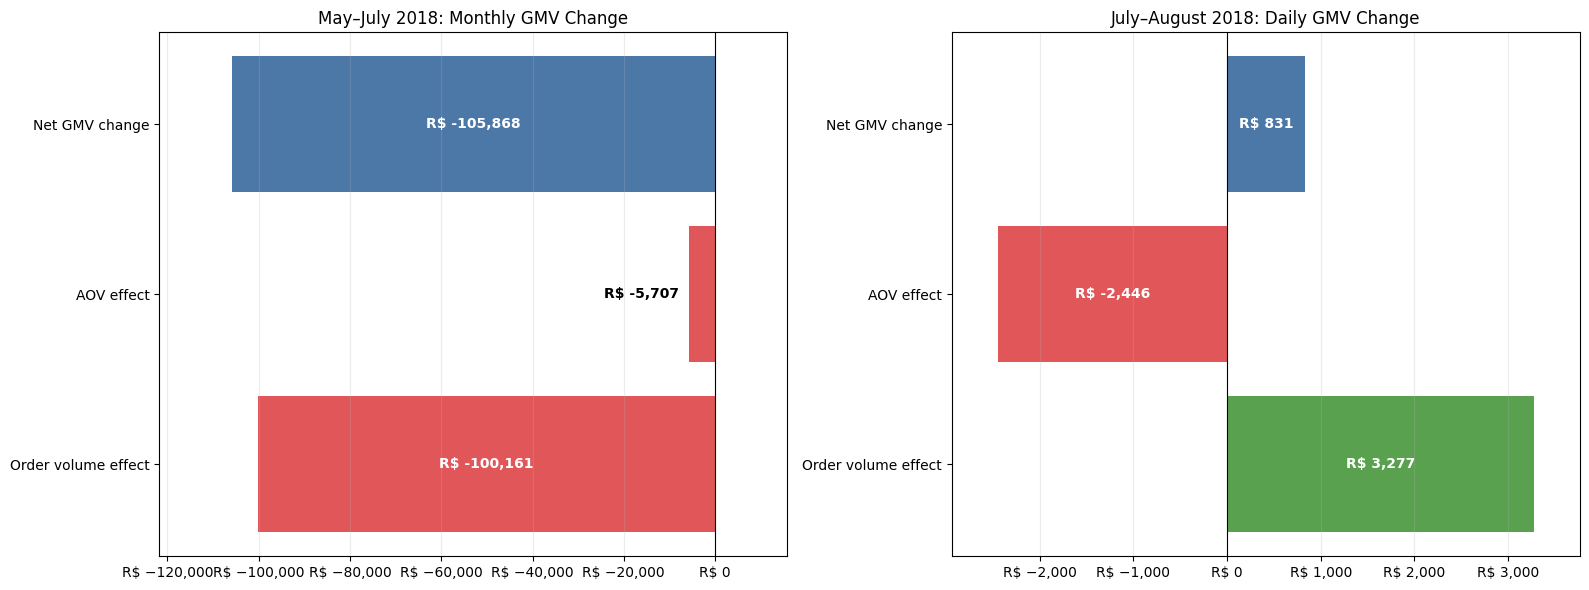

In [0]:
def plot_contributions(ax, values, title):
    colors = [
        "#59A14F" if values[0] >= 0 else "#E15759",
        "#59A14F" if values[1] >= 0 else "#E15759",
        "#4C78A8"
    ]

    bars = ax.barh(labels, values, color=colors)
    max_value = max(abs(value) for value in values)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))

    for bar, value in zip(bars, values):
        y = bar.get_y() + bar.get_height() / 2

        if abs(value) >= max_value * 0.15:
            ax.text(
                value / 2, y, f"R$ {value:,.0f}",
                ha="center", va="center",
                color="white", fontweight="bold"
            )
        else:
            offset = max_value * 0.02
            x = value - offset if value < 0 else value + offset
            alignment = "right" if value < 0 else "left"

            ax.text(
                x, y, f"R$ {value:,.0f}",
                ha=alignment, va="center",
                color="black", fontweight="bold"
            )

    minimum = min(0, min(values))
    maximum = max(0, max(values))
    ax.set_xlim(
        minimum - max_value * 0.15,
        maximum + max_value * 0.15
    )


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_contributions(
    axes[0], monthly_values,
    "May–July 2018: Monthly GMV Change"
)

plot_contributions(
    axes[1], daily_values,
    "July–August 2018: Daily GMV Change"
)

plt.tight_layout()
fig.savefig(
    figure_dir / "gmv_decomposition.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Decomposition findings

- Between May and July 2018, booked GMV declined by R$105,868.
- Order volume accounted for 94.61% of this decline.
- AOV accounted for only 5.39%, confirming that the full-month decline was primarily volume-driven.
- August showed a different pattern when normalized by active days.
- Higher daily order activity contributed R$3,277 to daily GMV.
- Lower AOV offset R$2,446, or approximately 74.6%, of this volume-driven improvement.
- As a result, daily GMV improved by only R$831.

**Conclusion:** The recent weakness had two stages: declining order volume in June–July, followed by recovering order activity but weaker basket value in August.

In [0]:
(
    monthly_gmv_decomposition.write
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("workspace.olist.monthly_gmv_decomposition")
)